# Credit Valuation Adjustment (CVA) dla portfela IRS + FX

**Projekt UEP — Spring 2026**
**Data wyceny:** 31.12.2025

---

## O czym jest ten notebook

Liczymy **CVA**. To korekta wyceny instrumentów o ryzyko kredytowe kontrahenta.
CVA to oczekiwana, zdyskontowana strata na wypadek defaultu kontrahenta.
Stratę ważymy prawdopodobieństwem tego defaultu:

$$\mathrm{CVA} = (1-R)\sum_{i=1}^{N} \mathrm{EE}(t_i)\, \mathrm{DF}(0,t_i)\, q(t_{i-1},t_i)$$

Oznaczenia: $\mathrm{EE}$ — oczekiwana ekspozycja. $\mathrm{DF}$ — czynnik dyskontowy.
$q$ — prawdopodobieństwo defaultu w okresie. $R$ — recovery rate.

### Analizowane instrumenty
- **FX Forward** (Buy EUR / Sell PLN). Nominał 1 mln EUR. Strike 4.4439. Termin 3 lata.
  Kupujemy EUR po stałym kursie. Zyskujemy, gdy EUR/PLN rośnie.
- **Receiver IRS** (EUR EURIBOR 3M). Nominał 10 mln EUR. Fixed 2.02% rocznie. Floating kwartalnie.
  Otrzymujemy stałą stopę. Zyskujemy, gdy stopy spadają.

### Kluczowe pojęcia
- **Netting**. Przy jednym kontrahencie ekspozycje się kompensują.
  Dlatego CVA portfela ≤ suma CVA pojedynczych (subaddytywność).
- **Variation Margin (VM)**. Zabezpieczenie wymieniane co miesiąc.
  Redukuje ekspozycję do zmian MtM w obrębie *margin period of risk*.

> **Uwaga:** notebook używa funkcji z `cva_final.py` (import niżej).
> Dlatego logika obliczeń jest identyczna ze skryptem.

## Importy i konfiguracja

Funkcje i stałe importujemy z modułu `cva_final`.
Dzięki temu wyniki są spójne ze skryptem `.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from IPython.display import display

import cva_final as cf
from cva_final import (
    # stale
    NOTIONAL_FX, K_FWD, NOTIONAL_IR, FIXED_RATE,
    T_YEARS, DT, N_STEPS, N_SIM, RECOVERY, LGD, RNG_SEED,
    # funkcje
    load_market_data, calibrate_volatilities, simulate_joint,
    price_fx_forward, price_irs_receiver,
    build_survival_curve, compute_cva, compute_cva_step,
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110

## 1. Parametry kontraktów

Tu są wszystkie stałe instrumentów i symulacji.
Horyzont to 3 lata. Krok jest miesięczny (`DT=1/12`, 36 kroków).
Liczymy 10 000 ścieżek MC. Recovery to 40% (→ LGD 60%).

In [2]:
params = pd.DataFrame([
    ("NOTIONAL_FX", NOTIONAL_FX, "EUR"),
    ("K_FWD",       K_FWD,       "EUR/PLN"),
    ("NOTIONAL_IR", NOTIONAL_IR, "EUR"),
    ("FIXED_RATE",  FIXED_RATE,  "rocznie"),
    ("T_YEARS",     T_YEARS,     "lata"),
    ("DT",          DT,          "lata (1 mies.)"),
    ("N_STEPS",     N_STEPS,     "kroki"),
    ("N_SIM",       N_SIM,       "sciezki"),
    ("RECOVERY",    RECOVERY,    "udzial"),
    ("LGD",         LGD,         "udzial"),
], columns=["Parametr", "Wartosc", "Jednostka"])

display(params.style.format({"Wartosc": "{:,.4g}"}).hide(axis="index"))

Parametr,Wartosc,Jednostka
NOTIONAL_FX,1e+06,EUR
K_FWD,4.444,EUR/PLN
NOTIONAL_IR,1e+07,EUR
FIXED_RATE,0.0202,rocznie
T_YEARS,3,lata
DT,0.08333,lata (1 mies.)
N_STEPS,36,kroki
N_SIM,1e+04,sciezki
RECOVERY,0.4,udzial
LGD,0.6,udzial


## 2. Dane rynkowe

Wczytujemy `Market_data.xlsx`.
Bierzemy kurs spot, płaskie stopy EUR/PLN, miesięczne czynniki dyskontowe i CDS.
Krzywa forward EUR/PLN rośnie, bo `r_PLN>r_EUR`.
Spready CDS rosną z tenorem.

In [3]:
md_data = load_market_data()
S0    = md_data["S0"]
r_EUR = md_data["r_EUR"]
r_PLN = md_data["r_PLN"]
curve = md_data["curve"]
cds_spreads = md_data["cds"]

# Krzywe dyskontowe (plaskie)
df_EUR = lambda t: np.exp(-r_EUR * t)
df_PLN = lambda t: np.exp(-r_PLN * t)

print(f"S0    (EUR/PLN spot)        = {S0:.4f}")
print(f"r_EUR (plaska stopa EUR)    = {r_EUR*100:.2f}%")
print(f"r_PLN (plaska stopa PLN)    = {r_PLN*100:.2f}%")
print(f"mu_fx (RN drift = r_PLN-r_EUR) = {(r_PLN-r_EUR)*100:.2f}%")

S0    (EUR/PLN spot)        = 4.2166
r_EUR (plaska stopa EUR)    = 2.00%
r_PLN (plaska stopa PLN)    = 3.75%
mu_fx (RN drift = r_PLN-r_EUR) = 1.75%


In [4]:
# Krzywa DF/forward - pierwsze i ostatnie 5 wierszy
curve_view = pd.concat([curve.head(5), curve.tail(5)])
display(curve_view.style.format({
    "month": "{:.0f}", "EUR_Rate": "{:.4f}", "PLN_rate": "{:.4f}",
    "EUR_DF": "{:.6f}", "PLN_DF": "{:.6f}", "EUR_PLN_fwd": "{:.4f}",
}).hide(axis="index"))

month,EUR_Rate,PLN_rate,EUR_DF,PLN_DF,EUR_PLN_fwd
0,0.0200,0.0375,1.000000,1.000000,4.2166
1,0.0200,0.0375,0.998335,0.996880,4.2228
2,0.0200,0.0375,0.996672,0.993769,4.2289
3,0.0200,0.0375,0.995012,0.990669,4.2351
4,0.0200,0.0375,0.993356,0.987578,4.2413
56,0.0200,0.0375,0.910890,0.839457,4.5754
57,0.0200,0.0375,0.909373,0.836838,4.5821
58,0.0200,0.0375,0.907859,0.834227,4.5888
59,0.0200,0.0375,0.906347,0.831624,4.5955
60,0.0200,0.0375,0.904837,0.829029,4.6022


In [5]:
# Notowania CDS
cds_df = pd.DataFrame(
    [(t, s * 1e4) for t, s in sorted(cds_spreads.items())],
    columns=["Tenor [y]", "Spread [bps]"]
)
display(cds_df.style.format({"Tenor [y]": "{:.1f}", "Spread [bps]": "{:.2f}"})
        .hide(axis="index"))

Tenor [y],Spread [bps]
0.5,30.50
1.0,39.40
2.0,69.35
3.0,96.70
4.0,123.33
5.0,152.07


## 3. Kalibracja zmienności i korelacji

Używamy plików CSV: Stooq EUR/PLN oraz ECB ESTR.
Estymujemy zmienności roczne. `sigma_fx` liczymy z log-zwrotów (GBM). `sigma_ir` z przyrostów ESTR (ABM).
Liczymy też korelację `rho` między innowacjami obu procesów na wspólnym oknie.
Netting wynika więc głównie z przeciwnych znaków MtM, nie z korelacji.

In [6]:
cal = calibrate_volatilities()
sigma_fx = cal["sigma_fx"]
sigma_ir = cal["sigma_ir"]
rho      = cal["rho"]

calib_df = pd.DataFrame([
    ("sigma_fx", f"{sigma_fx*100:.4f}%/rok",
     "Zmiennosc EUR/PLN (GBM) z log-zwrotow Stooq"),
    ("sigma_ir", f"{sigma_ir*1e4:.2f} bps/rok",
     "Zmiennosc short rate EUR (ABM) z przyrostow ESTR"),
    ("rho",      f"{rho:+.4f}",
     "Korelacja innowacji FX vs IR (wspolne okno)"),
    ("n_obs",    f"{cal['n_obs']}",
     "Liczba wspolnych obserwacji uzytych do korelacji"),
], columns=["Parametr", "Wartosc", "Interpretacja"])

display(calib_df.style.hide(axis="index"))

Parametr,Wartosc,Interpretacja
sigma_fx,4.3822%/rok,Zmiennosc EUR/PLN (GBM) z log-zwrotow Stooq
sigma_ir,49.59 bps/rok,Zmiennosc short rate EUR (ABM) z przyrostow ESTR
rho,+0.0248,Korelacja innowacji FX vs IR (wspolne okno)
n_obs,510,Liczba wspolnych obserwacji uzytych do korelacji


## 4. Symulacja Monte Carlo

Symulujemy łącznie dwa procesy.
EUR/PLN to GBM z dryfem risk-neutral `r_PLN-r_EUR`.
Short rate EUR to ABM z dryfem 0.
Korelację wprowadzamy przez dekompozycję Cholesky'ego.
Tablice mają kształt `(37, 10000)`. Korelacja empiryczna ≈ `rho`. Średnia EUR/PLN rośnie.

In [7]:
r0 = r_EUR                       # punkt startowy short rate
mu_fx_rn = r_PLN - r_EUR         # dryf RN dla EUR/PLN
time_grid = np.linspace(0, T_YEARS, N_STEPS + 1)

fx_paths, ir_paths = simulate_joint(S0, r0, sigma_fx, sigma_ir, rho, mu_fx_rn)

print(f"fx_paths shape: {fx_paths.shape}  (kroki+1, sciezki)")
print(f"ir_paths shape: {ir_paths.shape}")

dlnS = np.diff(np.log(fx_paths), axis=0).flatten()
dr   = np.diff(ir_paths, axis=0).flatten()
rho_emp = np.corrcoef(dlnS, dr)[0, 1]
print(f"\nKorelacja empiryczna w MC = {rho_emp:+.4f}  (target rho = {rho:+.4f})")

fx_paths shape: (37, 10000)  (kroki+1, sciezki)
ir_paths shape: (37, 10000)

Korelacja empiryczna w MC = +0.0248  (target rho = +0.0248)


In [8]:
# Statystyki opisowe co 6 miesiecy (krok 6)
idx_6m = list(range(0, N_STEPS + 1, 6))
rows = []
for i in idx_6m:
    rows.append((time_grid[i],
                 fx_paths[i].mean(), fx_paths[i].std(), fx_paths[i].min(), fx_paths[i].max(),
                 ir_paths[i].mean()*100, ir_paths[i].std()*100,
                 ir_paths[i].min()*100, ir_paths[i].max()*100))
stats_df = pd.DataFrame(rows, columns=[
    "t [y]", "FX_mean", "FX_std", "FX_min", "FX_max",
    "IR_mean[%]", "IR_std[%]", "IR_min[%]", "IR_max[%]"])
display(stats_df.style.format({
    "t [y]": "{:.1f}", "FX_mean": "{:.4f}", "FX_std": "{:.4f}",
    "FX_min": "{:.4f}", "FX_max": "{:.4f}",
    "IR_mean[%]": "{:.3f}", "IR_std[%]": "{:.3f}",
    "IR_min[%]": "{:.3f}", "IR_max[%]": "{:.3f}"}).hide(axis="index"))

t [y],FX_mean,FX_std,FX_min,FX_max,IR_mean[%],IR_std[%],IR_min[%],IR_max[%]
0.0,4.2166,0.0000,4.2166,4.2166,2.000,0.000,2.000,2.000
0.5,4.2527,0.1325,3.7642,4.7083,1.996,0.351,0.651,3.364
1.0,4.2895,0.1883,3.6622,5.0101,2.004,0.495,0.181,3.927
1.5,4.3273,0.2328,3.5318,5.2977,2.003,0.610,-0.572,4.460
2.0,4.3630,0.2721,3.3324,5.4207,2.007,0.705,-0.814,5.407
2.5,4.4002,0.3063,3.2019,5.7183,2.002,0.791,-0.777,5.327
3.0,4.4385,0.3364,3.1573,5.9278,2.002,0.864,-1.058,5.380


## 5. Wyceny Mark-to-Market po ścieżkach

Wyceniamy MtM każdego instrumentu na każdym kroku i ścieżce.
- **FX Forward** w PLN: $N\,(F(t,T)-K)\,DF_{PLN}$.
- **IRS** w EUR. Potem przeliczamy go do PLN po ścieżce FX (dla nettingu).
- **Portfel** w PLN: $MtM_{IRS}\cdot FX + MtM_{FX}$.

**MtM(0) ≈ 0** dla obu instrumentów. Kontrakty są at-market w t=0.
Percentyle pokazują rozrzut ekspozycji rosnący z czasem.

In [9]:
MtM_FX_pln   = price_fx_forward(fx_paths, r_EUR, r_PLN, time_grid)   # PLN
MtM_IRS_eur  = price_irs_receiver(ir_paths, r_EUR, time_grid)        # EUR
MtM_IRS_pln  = MtM_IRS_eur * fx_paths                                # PLN
MtM_port_pln = MtM_IRS_pln + MtM_FX_pln                              # PLN

sanity = pd.DataFrame([
    ("FX Forward [PLN]",  MtM_FX_pln[0].mean()),
    ("IRS [EUR]",         MtM_IRS_eur[0].mean()),
    ("IRS [PLN]",         MtM_IRS_pln[0].mean()),
    ("Portfel [PLN]",     MtM_port_pln[0].mean()),
], columns=["Instrument", "MtM(0) sredni"])
display(sanity.style.format({"MtM(0) sredni": "{:,.2f}"}).hide(axis="index"))
print("Oczekiwane ~0 -> kontrakty at-market w t=0.")

Instrument,MtM(0) sredni
FX Forward [PLN],-12.92
IRS [EUR],85.95
IRS [PLN],362.44
Portfel [PLN],349.52


Oczekiwane ~0 -> kontrakty at-market w t=0.


In [10]:
def mtm_percentiles(mtm, label):
    rows = []
    for i in idx_6m:
        p = np.percentile(mtm[i], [5, 25, 50, 75, 95])
        rows.append((time_grid[i], *p))
    return pd.DataFrame(rows, columns=[
        "t [y]", f"{label} p5", f"{label} p25", f"{label} p50",
        f"{label} p75", f"{label} p95"])

fx_pct  = mtm_percentiles(MtM_FX_pln,  "FX[PLN]")
irs_pct = mtm_percentiles(MtM_IRS_eur, "IRS[EUR]")

print("Percentyle MtM — FX Forward (PLN):")
display(fx_pct.style.format({c: "{:,.0f}" for c in fx_pct.columns[1:]} |
                            {"t [y]": "{:.1f}"}).hide(axis="index"))
print("Percentyle MtM — IRS (EUR):")
display(irs_pct.style.format({c: "{:,.0f}" for c in irs_pct.columns[1:]} |
                             {"t [y]": "{:.1f}"}).hide(axis="index"))

Percentyle MtM — FX Forward (PLN):


t [y],FX[PLN] p5,FX[PLN] p25,FX[PLN] p50,FX[PLN] p75,FX[PLN] p95
0.0,-13,-13,-13,-13,-13
0.5,"-203,743","-87,931","-3,918","83,882","209,101"
1.0,"-288,194","-126,435","-7,983","117,277","310,454"
1.5,"-364,057","-154,474","-8,375","146,348","383,383"
2.0,"-421,949","-190,219","-15,317","172,228","447,087"
2.5,"-480,082","-218,322","-18,396","193,765","515,507"
3.0,"-538,492","-239,298","-19,804","211,874","572,913"


Percentyle MtM — IRS (EUR):


t [y],IRS[EUR] p5,IRS[EUR] p25,IRS[EUR] p50,IRS[EUR] p75,IRS[EUR] p95
0.0,86,86,86,86,86
0.5,"86,326","94,739","100,735","106,597","115,041"
1.0,"-20,124","-8,308",-169,"8,365","20,437"
1.5,"75,460","90,190","100,611","110,897","125,561"
2.0,"-28,738","-11,958",-25,"11,834","29,131"
2.5,"68,410","87,351","100,559","113,816","133,433"
3.0,0,0,0,0,0


## 6. Profile Expected Exposure (EE)

$\mathrm{EE}(t)=\mathbb{E}[\max(MtM(t),0)]$. To średnia dodatnia ekspozycja.
Liczymy ją poprawnie jako `mean(max(MtM,0))`, a nie `max(mean,0)`.
Spadki widać po rocznych kuponach w t=1, 2, 3.
FX rośnie monotonicznie aż do terminu.
W t=3 EE FX jest najwyższe. To wypłata kontraktu w terminie, a nie zero.
EE z VM jest mocno stłumione. Zostaje tylko ryzyko jednego miesiąca.
EE(0)≈0, bo w punkcie startowym nie ma losowości.

In [11]:
EE_FX      = np.maximum(MtM_FX_pln,   0).mean(axis=1)
EE_IRS_eur = np.maximum(MtM_IRS_eur,  0).mean(axis=1)
EE_IRS_pln = np.maximum(MtM_IRS_pln,  0).mean(axis=1)
EE_port    = np.maximum(MtM_port_pln, 0).mean(axis=1)

# VM(T) = MtM_IRS(T-1)*FX(T-1) + MtM_FX(T-1);  VM(0)=0
VM = np.zeros_like(MtM_port_pln)
VM[1:] = MtM_IRS_eur[:-1] * fx_paths[:-1] + MtM_FX_pln[:-1]
EE_port_vm = np.maximum(MtM_port_pln - VM, 0).mean(axis=1)

# Tabela zbiorcza co 3 miesiace (w tys. PLN)
idx_3m = list(range(0, N_STEPS + 1, 3))
ee_tab = pd.DataFrame({
    "t [y]":      time_grid[idx_3m],
    "EE_FX":      EE_FX[idx_3m] / 1000,
    "EE_IRS_PLN": EE_IRS_pln[idx_3m] / 1000,
    "EE_port":    EE_port[idx_3m] / 1000,
    "EE_port_VM": EE_port_vm[idx_3m] / 1000,
})
display(ee_tab.style.format({
    "t [y]": "{:.2f}", "EE_FX": "{:.1f}k", "EE_IRS_PLN": "{:.1f}k",
    "EE_port": "{:.1f}k", "EE_port_VM": "{:.1f}k"}).hide(axis="index"))

t [y],EE_FX,EE_IRS_PLN,EE_port,EE_port_VM
0.00,0.0k,0.4k,0.3k,0.3k
0.25,34.8k,212.5k,212.1k,211.1k
0.50,50.1k,428.2k,427.3k,214.1k
0.75,61.7k,645.7k,644.8k,215.5k
1.00,71.7k,21.2k,74.7k,0.0k
1.25,81.3k,215.9k,232.6k,215.8k
1.50,89.4k,434.9k,436.8k,217.6k
1.75,96.9k,656.5k,654.4k,218.6k
2.00,104.8k,30.4k,108.4k,0.0k
2.25,111.7k,219.3k,256.2k,219.6k


## 7. CDS → krzywa przeżycia (interpolacja spreadów + bootstrap po siatce)

Kolejność operacji jest odwrócona:

1. **Interpolacja liniowa spreadów CDS** na każdy punkt siatki miesięcznej.
   Nie ekstrapolujemy poza ostatni filar.
2. **Bootstrap PS punkt po punkcie**. `PS[n]` liczymy analitycznie z równania CDS, wprost na siatce CVA.

Dzięki temu krzywa `PS(t)` jest gładka i malejąca.
Wtedy `q = PS[i-1] - PS[i] ≥ 0` z konstrukcji. Nie ma ujemnych składników CVA.

In [12]:
PS = build_survival_curve(cds_spreads, df_EUR, time_grid, recovery=RECOVERY)

# Weryfikacja poprawnosci krzywej
assert np.all(np.diff(PS) <= 0), "PS nie jest monotonicznie malejace"
assert np.all(PS >= 0),          "PS zawiera wartosci ujemne"
print(f"PS monotonicznie malejace: {bool(np.all(np.diff(PS) <= 0))}")
print(f"PS >= 0: {bool(np.all(PS >= 0))},  PS_min = {PS.min():.6f}")

# Spread interpolowany na siatke
_tenor_m  = [0.0] + [t * 12.0 for t in sorted(cds_spreads.keys())]
_spread_v = [0.0] + [cds_spreads[t] for t in sorted(cds_spreads.keys())]
spread_grid = interp1d(_tenor_m, _spread_v, kind="linear",
                       bounds_error=False,
                       fill_value=(0.0, max(_spread_v)))(time_grid * 12.0)

# Tabela co 6 miesiecy
idx_6m_ps = list(range(0, N_STEPS + 1, 6))
rows = []
for i in idx_6m_ps:
    pd_marg = (PS[i-1] - PS[i]) * 100 if i > 0 else 0.0
    rows.append((i, spread_grid[i] * 1e4, PS[i], pd_marg))
ps_df = pd.DataFrame(rows, columns=[
    "t [m]", "Spread CDS [bps]", "PS(t)", "PD_marginal [%]"])
display(ps_df.style.format({
    "t [m]": "{:.0f}", "Spread CDS [bps]": "{:.2f}",
    "PS(t)": "{:.6f}", "PD_marginal [%]": "{:.4f}"}).hide(axis="index"))

PS monotonicznie malejace: True
PS >= 0: True,  PS_min = 0.952089


t [m],Spread CDS [bps],PS(t),PD_marginal [%]
0,0.00,1.000000,0.0000
6,30.50,0.997457,0.0777
12,39.40,0.993440,0.0772
18,54.37,0.986428,0.1340
24,69.35,0.976957,0.1748
30,83.03,0.965607,0.2043
36,96.70,0.952089,0.2401


In [13]:
# PS w punktach odpowiadajacych filarom CDS (kontrola dopasowania)
rows = []
for t in sorted(cds_spreads.keys()):
    if t > T_YEARS:
        continue
    i = int(round(t / DT))
    rows.append((t, cds_spreads[t] * 1e4, PS[i], (1 - PS[i]) * 100))
pillar_df = pd.DataFrame(rows, columns=[
    "Tenor [y]", "Spread [bps]", "PS(t)", "PD_cum [%]"])
display(pillar_df.style.format({
    "Tenor [y]": "{:.1f}", "Spread [bps]": "{:.2f}",
    "PS(t)": "{:.6f}", "PD_cum [%]": "{:.4f}"}).hide(axis="index"))

Tenor [y],Spread [bps],PS(t),PD_cum [%]
0.5,30.50,0.997457,0.2543
1.0,39.40,0.993440,0.6560
2.0,69.35,0.976957,2.3043
3.0,96.70,0.952089,4.7911


## 8. Wyniki CVA

Liczymy CVA dla każdego instrumentu, dla portfela z nettingiem i dla portfela z VM.
Wszystko jest w PLN. IRS przeliczamy po ścieżce FX.
**Kluczowe pytanie projektu:** czy CVA portfela < suma CVA pojedynczych?

In [14]:
CVA_FX_pln   = compute_cva(EE_FX,      time_grid, df_PLN, PS)
CVA_IRS_eur  = compute_cva(EE_IRS_eur, time_grid, df_EUR, PS)
CVA_IRS_pln  = compute_cva(EE_IRS_pln, time_grid, df_PLN, PS)
CVA_port_pln = compute_cva(EE_port,    time_grid, df_PLN, PS)
CVA_port_vm  = compute_cva(EE_port_vm, time_grid, df_PLN, PS)

suma_single    = CVA_FX_pln + CVA_IRS_pln
netting_benefit = suma_single - CVA_port_pln
vm_reduction    = CVA_port_pln - CVA_port_vm

# Nominaly w PLN do wyrazenia CVA w % nominalu
nom_fx  = NOTIONAL_FX * S0
nom_irs = NOTIONAL_IR * S0
nom_port = nom_fx + nom_irs

cva_rows = [
    ("FX Forward",        CVA_FX_pln,    CVA_FX_pln/nom_fx*100),
    ("IRS (native PLN)",  CVA_IRS_pln,   CVA_IRS_pln/nom_irs*100),
    ("Suma standalone",   suma_single,   suma_single/nom_port*100),
    ("Portfel (netting)", CVA_port_pln,  CVA_port_pln/nom_port*100),
    ("Netting benefit",   netting_benefit, netting_benefit/nom_port*100),
    ("Portfel z VM",      CVA_port_vm,   CVA_port_vm/nom_port*100),
    ("Redukcja przez VM", vm_reduction,  vm_reduction/nom_port*100),
]
cva_df = pd.DataFrame(cva_rows, columns=[
    "Instrument", "CVA [PLN]", "CVA [% nominalu PLN]"])
display(cva_df.style.format({
    "CVA [PLN]": "{:,.2f}", "CVA [% nominalu PLN]": "{:.4f}%"}).hide(axis="index"))

print(f"Czy CVA_portfela < suma CVA pojedynczych?  -> "
      f"{'TAK' if CVA_port_pln < suma_single else 'NIE'} "
      f"(netting {netting_benefit/suma_single*100:.2f}%)")
print(f"Redukcja CVA przez VM: {vm_reduction/CVA_port_pln*100:.2f}%")

Instrument,CVA [PLN],CVA [% nominalu PLN]
FX Forward,"2,695.13",0.0639%
IRS (native PLN),"9,555.08",0.0227%
Suma standalone,"12,250.20",0.0264%
Portfel (netting),"10,237.21",0.0221%
Netting benefit,"2,013.00",0.0043%
Portfel z VM,"1,874.71",0.0040%
Redukcja przez VM,"8,362.50",0.0180%


Czy CVA_portfela < suma CVA pojedynczych?  -> TAK (netting 16.43%)
Redukcja CVA przez VM: 81.69%


## 9. Wykresy

Rysujemy cztery figury: FX, IRS, portfel i portfel z VM.
Każda ma dwa panele. Po lewej EE (linia), po prawej CVA per-step (słupki).
Figury wyświetlamy (`plt.show()`) i zapisujemy do PNG.

In [15]:
LABEL_TIMES = (0.5, 1.0, 1.5, 2.0, 2.5, 3.0)

def _annotate(ax, xs, ys, color, va="bottom"):
    for x, v in zip(xs, ys):
        if not any(abs(x - t) < 1e-6 for t in LABEL_TIMES):
            continue
        if abs(v) < 1:
            continue
        ax.annotate(f"{v/1000:.1f}k", xy=(x, v), ha="center", va=va,
                    fontsize=6, color=color)

def _annotate_bars(ax, xs, ys, color):
    for x, v in zip(xs, ys):
        if not any(abs(x - t) < 1e-6 for t in LABEL_TIMES):
            continue
        if abs(v) < 1:
            continue
        ax.annotate(f"{v/1000:.1f}k", xy=(x, v), ha="center", va="bottom",
                    fontsize=6, color=color)

def _ee_panel(ax, ee, label, title, color="#004488"):
    ax.plot(time_grid, ee, color=color, lw=1.8, marker="o", ms=3, label=label)
    ax.set_xlabel("Czas [lata]"); ax.set_ylabel("EE [PLN]")
    ax.set_title(title); ax.grid(alpha=0.3)
    _annotate(ax, time_grid, ee, color=color, va="bottom")
    ax.legend(fontsize=8)

def _cva_bar_panel(ax, cva_step, label, title, color="darkorange"):
    ax.bar(time_grid, cva_step, width=DT*0.4, alpha=0.6, color=color, label=label)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("Czas [lata]"); ax.set_ylabel("CVA step [PLN]")
    ax.set_title(title); ax.grid(alpha=0.3)
    _annotate_bars(ax, time_grid, cva_step, color=color)
    ax.legend(fontsize=8)

# CVA per-step do wykresow
step_CVA_FX      = compute_cva_step(EE_FX,      time_grid, df_PLN, PS)
step_CVA_IRS_pln = compute_cva_step(EE_IRS_pln, time_grid, df_PLN, PS)
step_CVA_port    = compute_cva_step(EE_port,    time_grid, df_PLN, PS)
step_CVA_port_vm = compute_cva_step(EE_port_vm, time_grid, df_PLN, PS)

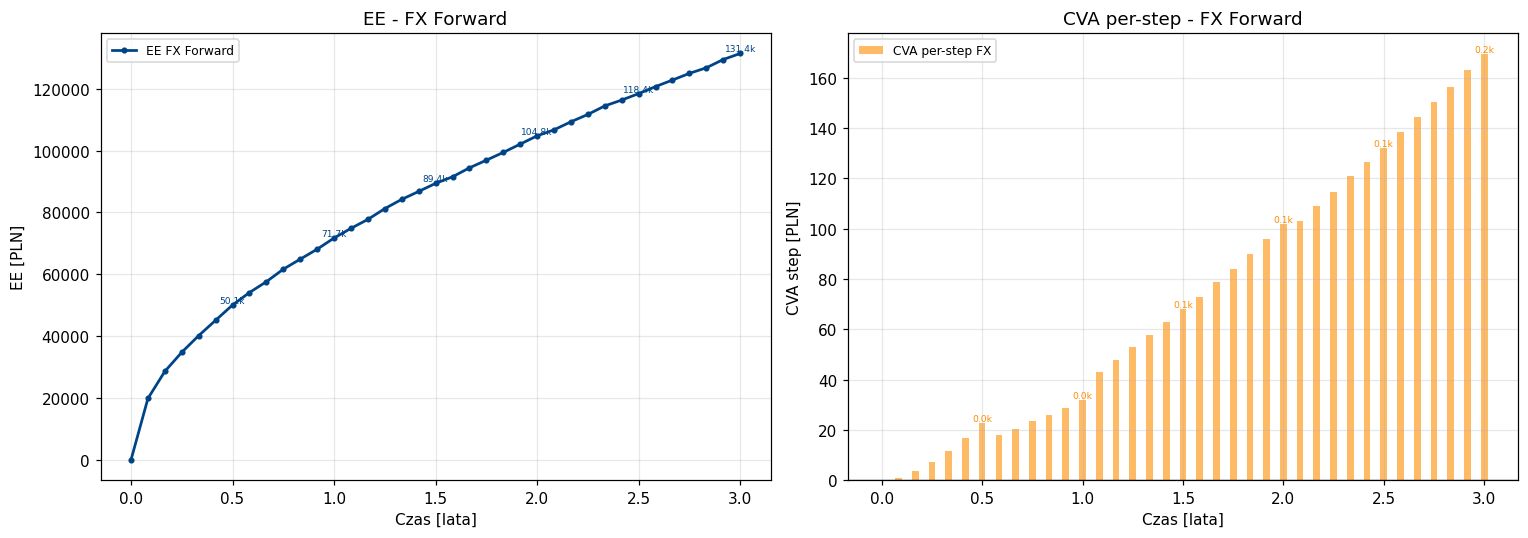

In [16]:
# Figura 1 - FX Forward
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_ee_panel(axes[0], EE_FX, "EE FX Forward", "EE - FX Forward")
_cva_bar_panel(axes[1], step_CVA_FX, "CVA per-step FX", "CVA per-step - FX Forward")
plt.tight_layout(); plt.savefig("cva_fx.png", dpi=150); plt.show()

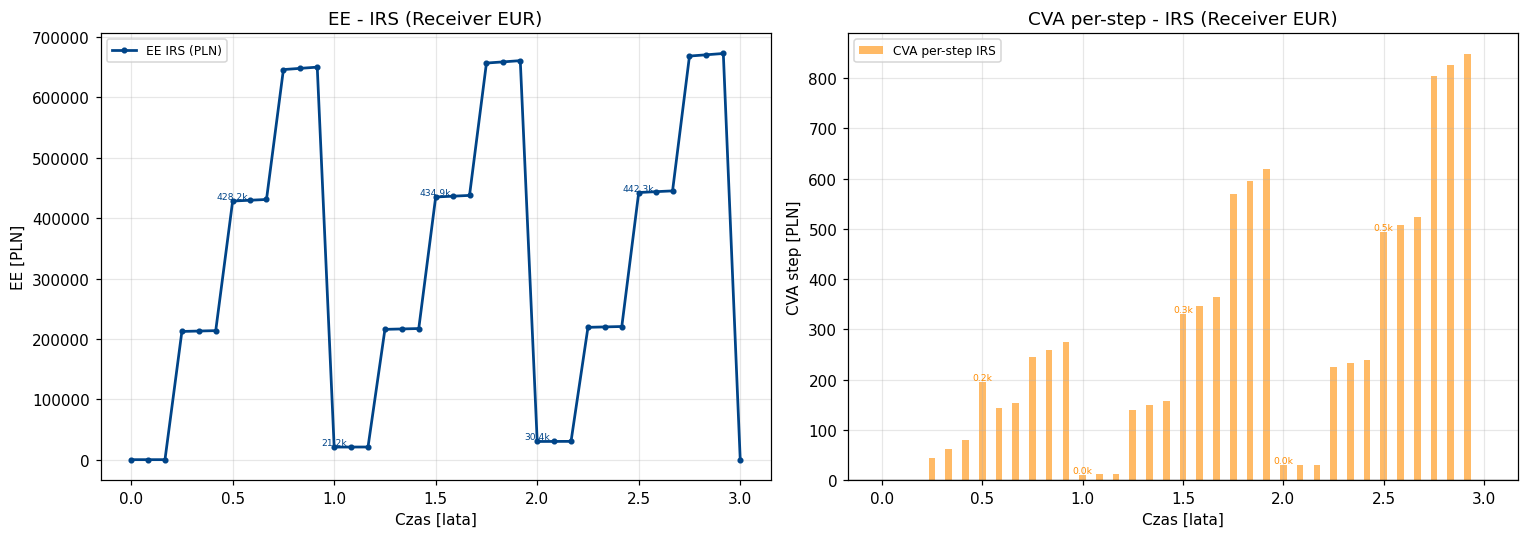

In [17]:
# Figura 2 - IRS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_ee_panel(axes[0], EE_IRS_pln, "EE IRS (PLN)", "EE - IRS (Receiver EUR)")
_cva_bar_panel(axes[1], step_CVA_IRS_pln, "CVA per-step IRS",
               "CVA per-step - IRS (Receiver EUR)")
plt.tight_layout(); plt.savefig("cva_irs.png", dpi=150); plt.show()

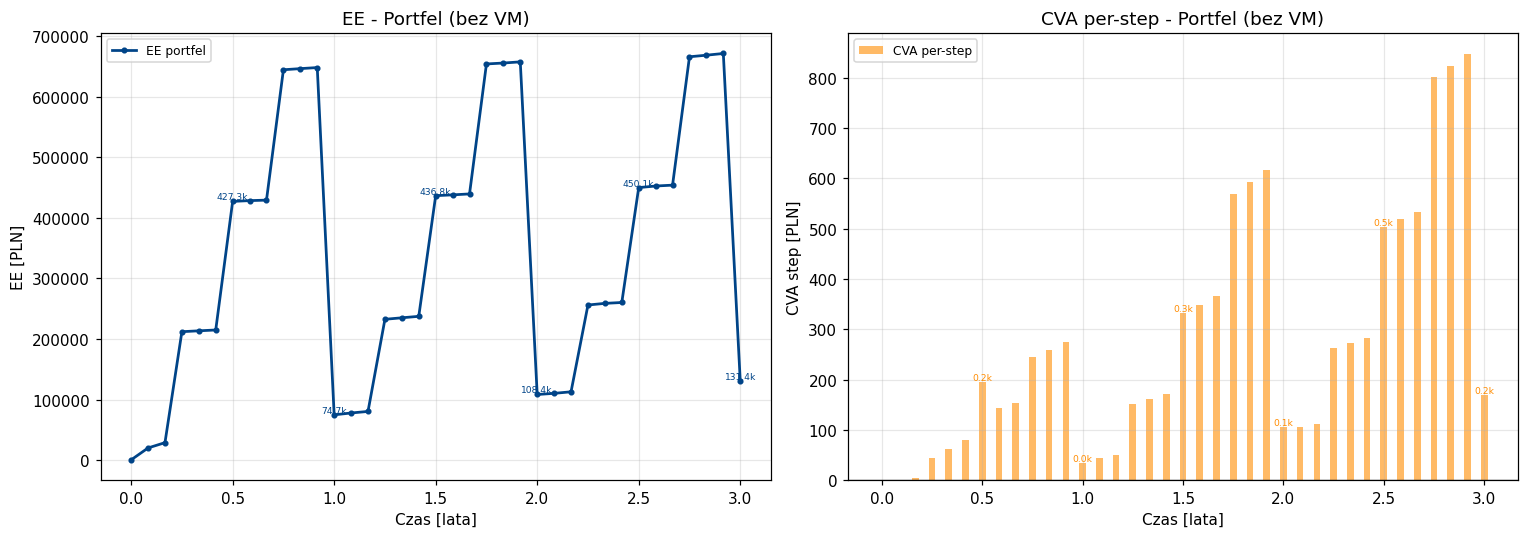

In [18]:
# Figura 3 - Portfel bez VM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_ee_panel(axes[0], EE_port, "EE portfel", "EE - Portfel (bez VM)")
_cva_bar_panel(axes[1], step_CVA_port, "CVA per-step", "CVA per-step - Portfel (bez VM)")
plt.tight_layout(); plt.savefig("cva_portfel.png", dpi=150); plt.show()

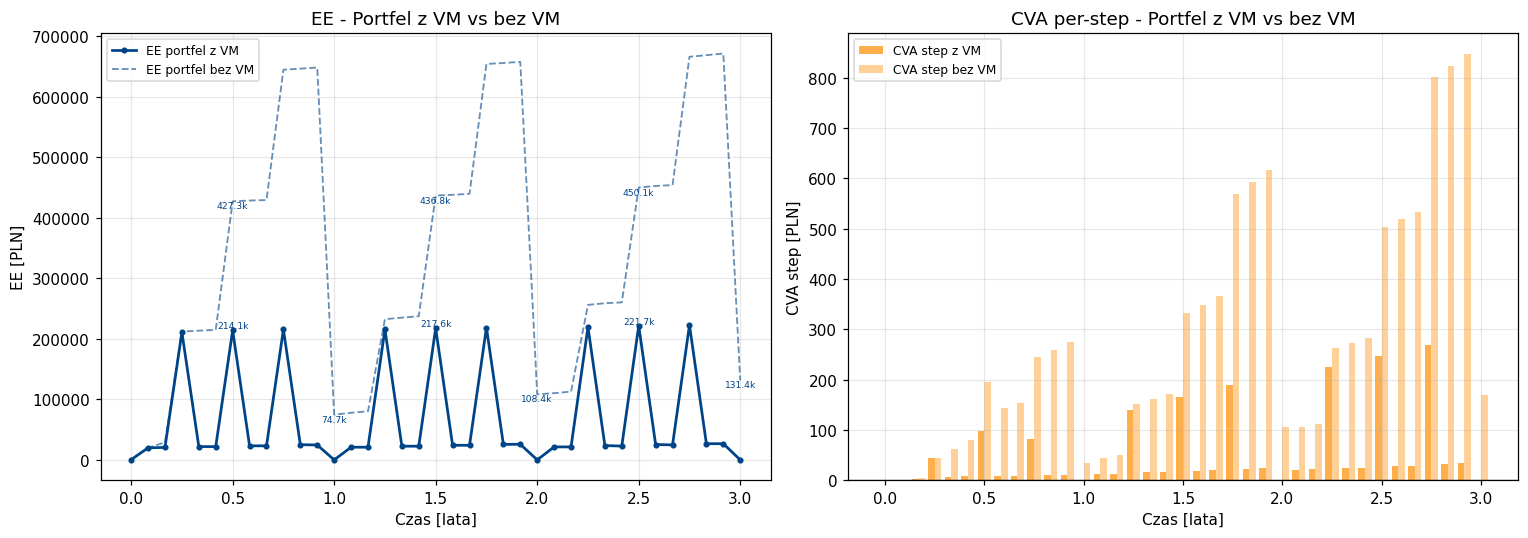

In [19]:
# Figura 4 - Portfel z VM vs bez VM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ee_color = "#004488"
ax.plot(time_grid, EE_port_vm, color=ee_color, lw=1.8, marker="o", ms=3,
        label="EE portfel z VM")
ax.plot(time_grid, EE_port, color=ee_color, lw=1.2, ls="--", alpha=0.6,
        label="EE portfel bez VM")
_annotate(ax, time_grid, EE_port_vm, color=ee_color, va="bottom")
_annotate(ax, time_grid, EE_port,    color=ee_color, va="top")
ax.set_xlabel("Czas [lata]"); ax.set_ylabel("EE [PLN]")
ax.set_title("EE - Portfel z VM vs bez VM"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
bar_w = DT * 0.4
ax.bar(time_grid - bar_w/2, step_CVA_port_vm, width=bar_w, alpha=0.7,
       color="darkorange", label="CVA step z VM")
ax.bar(time_grid + bar_w/2, step_CVA_port, width=bar_w, alpha=0.4,
       color="darkorange", label="CVA step bez VM")
ax.axhline(0, color="black", lw=0.8)
_annotate_bars(ax, time_grid - bar_w/2, step_CVA_port_vm, color="darkorange")
_annotate_bars(ax, time_grid + bar_w/2, step_CVA_port,    color="darkorange")
ax.set_xlabel("Czas [lata]"); ax.set_ylabel("CVA step [PLN]")
ax.set_title("CVA per-step - Portfel z VM vs bez VM"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("cva_portfel_vm.png", dpi=150); plt.show()